In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
try:
    import openpyxl
except Exception as e:
    import warnings
    warnings.warn(str(e))
    warnings.warn("pip installing openpyxl...")
    ! pip3 install openpyxl
    try:
        import openpyxl
    except Exception as e:
        raise e
from tvb.datatypes.connectivity import Connectivity
from tvb.simulator.simulator import Simulator
from tvb.simulator.noise import Additive
from tvb.simulator.integrators import EulerDeterministic, EulerStochastic, HeunStochastic
from tvb.simulator.coupling import Linear as LinearCoupling
from tvb.simulator.models.linear import Linear
from tvb.simulator.monitors import Raw
from tvb.contrib.simulator.models.polynomial import Polynomial, PolynomialCoupling, SparseHistory64


ORDER = 7  # 7  # select between 1 and 7
N_MODES = 1
NOISE = 0.1
DT = 0.1
T = 50.0
COUPLING = True
HISTORY64 = True

CoefFilePath = "./polynomial_model_Kashyap_etal_2025_NatureCommunications/Fig11_source.xlsx"
CorticalRegionsFilePath = "./polynomial_model_Kashyap_etal_2025_NatureCommunications/roi_names_abr.txt"
CorticalROIreorder = "./polynomial_model_Kashyap_etal_2025_NatureCommunications/roi_reorder.txt"

In [2]:
#### Names of the cortical brain regions

# roi_names = np.genfromtxt(CorticalRegionsFilePath,dtype='str')
# roi_yeo = np.loadtxt('yeo66network.txt')
# roi_names_abr = np.genfromtxt('roi_names_abr.txt', dtype = 'str')

# fmri_LUT2=np.loadtxt('C:\\Users\\amrit\\Documents\\roi_reorder.txt')


# roi_reorder = np.array([roi_names[int(fmri_LUT2[i])-1] for i in range(70)])
# roi_yeo_reorder =  np.array([roi_yeo[int(fmri_LUT2[i])-1] for i in range(70)])
# roi_abr_reorder =  np.array([roi_names_abr[int(fmri_LUT2[i])-1] for i in range(70)])

# for i in range(70):
#     roi_reorder[int(fmri_LUT2[i])-1] = roi_names[i]
#     roi_yeo_reorder[int(fmri_LUT2[i])-1] = roi_yeo[i]
#     roi_abr_reorder[int(fmri_LUT2[i])-1] = roi_names_abr[i]

    
# roi_cortical = roi_reorder[:68]
# roi_yeo_cortical = roi_yeo_reorder[:68]
# roi_abr_cortical = roi_abr_reorder[:68]

# #subcortical naming convention is different than cortical, for plotting purposes of using ggseg.
# #Trust me I am as annoyed as you are
# subcortical_l = ['Left-Accumbens','Left-Amygdala', 'Left-Hippocampus', 'Left-Pallidum','Left-Putamen', 'Left-Caudate', 'Left-Thalamus', 'Left-Cerebellum']
# subcortical_r = ['Right-Accumbens','Right-Amygdala', 'Right-Hippocampus', 'Right-Pallidum' ,'Right-Putamen', 'Right-Caudate', 'Right-Thalamus', 'Right-Cerebellum']

# roi_all = np.concatenate([subcortical_r[::-1], roi_cortical, subcortical_l])
# print(roi_all)


def construct_conn():
    region_labels = ['Right-Cerebellum', 'Right-Thalamus', 'Right-Caudate', 'Right-Putamen',
     'Right-Pallidum', 'Right-Hippocampus', 'Right-Amygdala', 'Right-Accumbens',
     'insula_right', 'entorhinal_right', 'parahippocampal_right',
     'temporalpole_right', 'frontalpole_right', 'fusiform_right',
     'transversetemporal_right', 'lateraloccipital_right',
     'superiorparietal_right', 'inferiortemporal_right',
     'inferiorparietal_right', 'supramarginal_right', 'bankssts_right',
     'middletemporal_right', 'superiortemporal_right', 'postcentral_right',
     'precentral_right', 'caudalmiddlefrontal_right', 'parsopercularis_right',
     'parstriangularis_right', 'rostralmiddlefrontal_right',
     'parsorbitalis_right', 'lateralorbitofrontal_right',
     'caudalanteriorcingulate_right', 'rostralanteriorcingulate_right',
     'superiorfrontal_right', 'medialorbitofrontal_right', 'lingual_right',
     'pericalcarine_right', 'cuneus_right', 'paracentral_right',
     'isthmuscingulate_right', 'precuneus_right', 'posteriorcingulate_right',
     'posteriorcingulate_left', 'precuneus_left', 'isthmuscingulate_left',
     'paracentral_left', 'cuneus_left', 'pericalcarine_left', 'lingual_left',
     'medialorbitofrontal_left', 'superiorfrontal_left',
     'rostralanteriorcingulate_left', 'caudalanteriorcingulate_left',
     'lateralorbitofrontal_left', 'parsorbitalis_left',
     'rostralmiddlefrontal_left', 'parstriangularis_left',
     'parsopercularis_left', 'caudalmiddlefrontal_left', 'precentral_left',
     'postcentral_left', 'superiortemporal_left', 'middletemporal_left',
     'bankssts_left', 'supramarginal_left', 'inferiorparietal_left',
     'inferiortemporal_left', 'superiorparietal_left', 'lateraloccipital_left',
     'transversetemporal_left', 'fusiform_left', 'frontalpole_left',
     'temporalpole_left', 'parahippocampal_left', 'entorhinal_left',
     'insula_left', 'Left-Accumbens', 'Left-Amygdala', 'Left-Hippocampus',
     'Left-Pallidum', 'Left-Putamen', 'Left-Caudate', 'Left-Thalamus',
     'Left-Cerebellum']
    region_labels = np.array(region_labels)
    print("region_labels = ", region_labels)
    N_NODES = len(region_labels)
    print("N_NODES = ", N_NODES)

    cortical = np.ones((N_NODES,)).astype("bool")
    cortical[:8] = False
    cortical[-8:] = False
    assert cortical.sum() == 68
    hemispheres = np.ones((N_NODES,)).astype("bool")
    hemispheres[42:] = False
    assert hemispheres.sum() == 42
    weights = np.ones((N_NODES, N_NODES)).astype("f")
    jj = np.arange(N_NODES).astype("i")
    weights[jj, jj] = 0.0
    assert np.all(weights[jj, jj] == 0)
    assert weights.sum() == N_NODES*N_NODES - N_NODES
    tract_lengths = 0.0*weights
    assert tract_lengths.sum() == 0

    conn = Connectivity(region_labels=region_labels, weights=weights, tract_lengths=tract_lengths, 
                        centres=np.random.normal(size=(N_NODES, 3)), hemispheres=hemispheres, cortical=cortical)
    conn.configure()
    return conn

conn = construct_conn()
N_NODES = conn.number_of_regions

region_labels =  ['Right-Cerebellum' 'Right-Thalamus' 'Right-Caudate' 'Right-Putamen'
 'Right-Pallidum' 'Right-Hippocampus' 'Right-Amygdala' 'Right-Accumbens'
 'insula_right' 'entorhinal_right' 'parahippocampal_right'
 'temporalpole_right' 'frontalpole_right' 'fusiform_right'
 'transversetemporal_right' 'lateraloccipital_right'
 'superiorparietal_right' 'inferiortemporal_right'
 'inferiorparietal_right' 'supramarginal_right' 'bankssts_right'
 'middletemporal_right' 'superiortemporal_right' 'postcentral_right'
 'precentral_right' 'caudalmiddlefrontal_right' 'parsopercularis_right'
 'parstriangularis_right' 'rostralmiddlefrontal_right'
 'parsorbitalis_right' 'lateralorbitofrontal_right'
 'caudalanteriorcingulate_right' 'rostralanteriorcingulate_right'
 'superiorfrontal_right' 'medialorbitofrontal_right' 'lingual_right'
 'pericalcarine_right' 'cuneus_right' 'paracentral_right'
 'isthmuscingulate_right' 'precuneus_right' 'posteriorcingulate_right'
 'posteriorcingulate_left' 'precuneus_left

In [3]:
def load_pCoef(CoefFilePath):
    return pd.read_excel(CoefFilePath, sheet_name="cmean").values[2:, 1:]
    
    
def construct_pCoef(pdata):
    print("pdata.shape = ", pdata.shape)
    N_NODES = pdata.shape[0]
    print("N_NODES = ", N_NODES)
    order = int(pdata.shape[1]/N_NODES)
    print("order = ", order)

    p = np.zeros((N_NODES, N_NODES, N_MODES, order+1))
    for io in range(1, order+1):
        start = (io-1) * N_NODES
        stop = start + N_NODES
        p[:, :, 0, io] = pdata[:, np.arange(start, stop).astype("i")]

    print("p.shape = ", p.shape)
    return p, order


def load_construct_pCoef(CoefFilePath):
    p, order = construct_pCoef(load_pCoef(CoefFilePath))
    pdiag = np.array(np.einsum("jj...->j...", p))
    assert pdiag.shape == (N_NODES, N_MODES, order+1)
    print("pdiag.shape = ", pdiag.shape)
    jj = np.arange(N_NODES).astype("i")
    pcoupl = np.array(p)
    pcoupl[jj, jj] = 0.0
    assert np.all(pcoupl[jj, jj] == 0)
    return pdiag, pcoupl, p, order


pdiag, pcoupl, p, order = load_construct_pCoef(CoefFilePath)
p = p[:, :, :, :ORDER+1]
print("final p.shape = ", p.shape)
pdiag = pdiag[:, :, :ORDER+1]
print("final pdiag.shape = ", pdiag.shape)
pcoupl = pcoupl[:, :, :, :ORDER+1]
print("final pcoupl.shape = ", pcoupl.shape)
order = ORDER

# For testing:
p[:, :, :, 2:] = 0.0
print("p[:, :, :, 2:].max() = ",p[:, :, :, 2:].max())
pdiag[:, :, 2:] = 0.0
print("pdiag[:, :, 2:].max() = ", pdiag[:, :, 2:].max())
pcoupl[:, :, :, 2:] = 0.0
print("pcoupl[:, :, :, 2:].max() = ", pcoupl[:, :, :, 2:].max())

if COUPLING is False:
    print("pdiag [min, mean, max] = ", [pdiag.min(), pdiag.mean(), pdiag.max()])
    pcoupl *= 0.0
    print("pcoupl [min, mean, max] = ", [pcoupl.min(), pcoupl.mean(), pcoupl.max()])
    p *= 0
    jj = np.arange(N_NODES).astype("i")
    for jjj in jj:
        p[jjj, jjj] = pdiag[jjj]
    p = p[:, :, :, :ORDER+1]
    print("p [min, mean, max] = ", [p.min(), p.mean(), p.max()])

pdata.shape =  (84, 588)
N_NODES =  84
order =  7
p.shape =  (84, 84, 1, 8)
pdiag.shape =  (84, 1, 8)
final p.shape =  (84, 84, 1, 8)
final pdiag.shape =  (84, 1, 8)
final pcoupl.shape =  (84, 84, 1, 8)
p[:, :, :, 2:].max() =  0.0
pdiag[:, :, 2:].max() =  0.0
pcoupl[:, :, :, 2:].max() =  0.0


In [4]:
sim = Simulator()
sim.connectivity = conn
sim.coupling = PolynomialCoupling(p=pcoupl)
sim.model = Polynomial(p=pdiag)
sim.model.number_of_modes = N_MODES
if NOISE > 0.0:
    sim.integrator = EulerStochastic(dt=DT, 
                                     noise=Additive(nsig=np.array([NOISE] + [0]*(order-1))))
else:
    sim.integrator = EulerDeterministic(dt=DT)  # EulerDeterministic(dt=0.1)
sim.monitors = (Raw(), )
sim.simulation_length = T
initial_conditions_shape = (1, ORDER, sim.connectivity.weights.shape[0], sim.model.number_of_modes)
sim.initial_conditions = 0.001*np.random.normal(size=initial_conditions_shape)
sim.configure()
if HISTORY64:
    sim.history = SparseHistory64.from_simulator(sim)


In [5]:
sim.history.buffer.dtype

dtype('float64')

In [6]:
results = sim.run()

In [7]:
[sim.model.state_variable_dfuns, sim.model.parameter_names, 
 sim.model.state_variables, sim.model.non_integrated_variables, 
 sim.model.state_variable_range, sim.model.variables_of_interest,
 sim.model.state_variable_mask,
 sim.model._nvar, sim.model.cvar]

[{'x': 'lamda * (p0 + p1*x + p2*x^2 + p3*x^3 + p4*x^4 + p5*x^5 + p6*x^6 + p7*x^7)'},
 ('lamda', 'p', 'p0', 'p1', 'p2', 'p3', 'p4', 'p5', 'p6', 'p7'),
 ('x', 'x2', 'x3', 'x4', 'x5', 'x6', 'x7'),
 ('x2', 'x3', 'x4', 'x5', 'x6', 'x7'),
 {'x': array([-1,  1]),
  'x2': array([0, 1]),
  'x3': array([-1,  1]),
  'x4': array([0, 1]),
  'x5': array([-1,  1]),
  'x6': array([0, 1]),
  'x7': array([-1,  1])},
 ('x',),
 array([ True, False, False, False, False, False, False]),
 7,
 array([0, 1, 2, 3, 4, 5, 6], dtype=int32)]

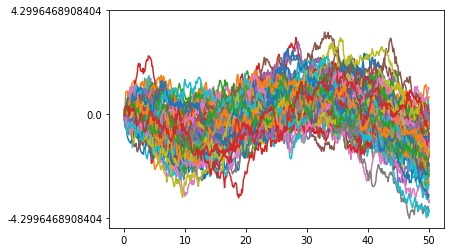

In [8]:
ymax = np.abs(results[0][1][:, :, :, 0]).max()
if np.isnan(ymax):
    plt.plot(results[0][0], results[0][1][:, :, :, 0].squeeze());
    ax = plt.gca()
    ax.set_ylim([-10.0, 10.0])
else:
    plt.plot(results[0][0], results[0][1][:, :, :, 0].squeeze()/ymax);
    yticks = np.array([-1.0, 0.0, 1.0])
    ax = plt.gca()
    ax.set_yticks(yticks)
    ax.set_yticklabels(yticks*ymax)

In [9]:
from tvb.contrib.tests.model.model_test import TestPolynomialModel
test = TestPolynomialModel(connectivity=sim.connectivity, p=p, verbose=2)
test.T = sim.simulation_length
test.HISTORY64 = False
test.test_polynomial_model()


polynomial order=7
2025-10-08 17:07:30,279 - WARNING - tvb.simulator.integrators - random_state supplied for non-stochastic integration
max error =  1.2145452837897253e-09


In [10]:
from tvb.contrib.tests.model.model_test import TestPolynomialModel
test = TestPolynomialModel(connectivity=sim.connectivity, p=p, verbose=2)
test.T = sim.simulation_length
test.HISTORY64 = True
test.test_polynomial_model()


polynomial order=7
2025-10-08 17:07:40,151 - WARNING - tvb.simulator.integrators - random_state supplied for non-stochastic integration
max error =  8.326672684688674e-17


In [11]:
if "EulerDeterministic" in str(type(sim.integrator)):

    from tvb.contrib.tests.model.model_test import polyint_Euler

    x, t = polyint_Euler(sim, p[:, :, 0, :])

    xmax = np.abs(x).max()
    if np.isnan(xmax):
        plt.plot(t, x);
        ax = plt.gca()
        ax.set_ylim([-10.0, 10.0])
    else:
        plt.plot(t, x/xmax);
        yticks = np.array([-1.0, 0.0, 1.0])
        ax = plt.gca()
        ax.set_yticks(yticks)
        ax.set_yticklabels(yticks*xmax)

    res = results[0][1].squeeze()
    targres = x.squeeze()
    try:
        print(np.abs(res - targres).max())
        assert np.allclose(res, targres, rtol=1e-03, atol=1e-03)
    except Exception as e:
        print(np.abs(res - targres).max())
        print(res.shape)
        print(targres.shape)
        print([res.min(), res.mean(), res.max()])
        print([targres.min(), targres.mean(), targres.max()])
        print(res)
        print(targres)
        raise e

In [12]:
np.sqrt(2*NOISE*DT)  # 0.13 in SINDy's notebook

0.14142135623730953

In [13]:
from tvb.contrib.tests.model.model_test import TestPolynomialModel
test = TestPolynomialModel(verbose=2)
test.test_polynomial_model()

2025-10-08 17:07:50,140 - WARNING - tvb.basic.readers - File 'hemispheres' not found in ZIP.

polynomial order=3
2025-10-08 17:07:50,148 - WARNING - tvb.simulator.integrators - random_state supplied for non-stochastic integration
max error =  0.0027804787083770335
polynomial order =  3
max error =  0.0027804787083770335
res.shape =  (2, 76)
targres.shape =  (2, 76)
[res.min(), res.mean(), res.max()] =  [-0.25265040002125067, 0.0044189932140620055, 0.2075690058842958]
[targres.min(), targres.mean(), targres.max()] =  [-0.25183704814512176, 0.004329161769510313, 0.20986028523071001]
res =  [[ 2.90830407e-02  1.34446011e-01  4.93648693e-02 -8.36490157e-02
  -1.46611834e-01  1.21174463e-02 -2.48450356e-01  1.54643134e-01
  -1.22808940e-02  4.13146526e-02 -9.22364180e-02  2.57607276e-02
   7.50607855e-02  2.32022305e-02  1.45175720e-02  6.50905134e-02
   1.34211764e-02  5.94992347e-02  4.15458720e-03  9.06667312e-02
   8.94063756e-02  9.08682510e-02 -2.50744862e-02  5.79851700e-02
   1.2214

AssertionError: 